# Handling Mixed variables

### Preparing dataset to understand how to handle <b>Mixed Variables</b>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('E:/Dataset/titanic-Dataset.csv', usecols=['Survived', 'SibSp', 'Parch', 'Ticket', 'Cabin'])

In [3]:
print(df.columns)
df.sample()

Index(['Survived', 'SibSp', 'Parch', 'Ticket', 'Cabin'], dtype='object')


,Survived,SibSp,Parch,Ticket,Cabin
123,1,0,0,27267,E101


In [4]:
df['family'] = df['SibSp']+df['Parch']

In [5]:
df['family'] = df['family'].replace(0, 'A')

# df.loc[df['family']==0, 'family'] = 'A'

In [6]:
df.drop(columns=['SibSp', 'Parch'], inplace=True)

In [7]:
df.sample(2)

,Survived,Ticket,Cabin,family
376,1,C 7077,NaN,A
308,0,P/PP 3381,NaN,1


### Analyzing dataset

In [8]:
df['family'].unique()

array([1, 'A', 4, 2, 6, 5, 3, 7, 10], dtype=object)

In [9]:
df['family'].value_counts()

family
A     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

Text(0.5, 1.0, 'Passenger travelling with')

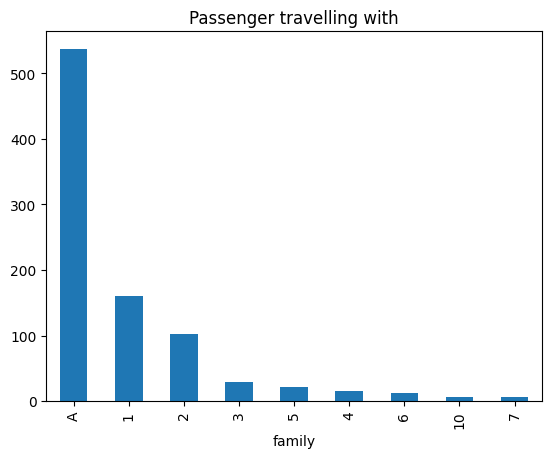

In [10]:
fig = df['family'].value_counts().plot.bar()
fig.set_title("Passenger travelling with")

### Handling Mixed variables

#### Method-I

In [11]:
df['family_numerical'] = pd.to_numeric(df['family'], errors='coerce', downcast='integer')
# df['family_numerical'] = pd.to_numeric(df['family'], errors='coerce')

##### - In the above cell, there are two lines and both does the same thing bcz <b>downcast='integer'</b> means if possible then convert to lower integer type like int32, int16
##### - <b>errors='coerce'</b> do the main thing, if conversion will possible then convert, and if not then replace with NaN

In [12]:
df['family_categorical'] = np.where(df['family_numerical'].isnull(), df['family'], np.nan)

In [13]:
df.head()

,Survived,Ticket,Cabin,family,family_numerical,family_categorical
0,0,A/5 21171,NaN,1,1.0,NaN
1,1,PC 17599,C85,1,1.0,NaN
2,1,STON/O2. 3101282,NaN,A,NaN,A
3,1,113803,C123,1,1.0,NaN
4,0,373450,NaN,A,NaN,A


#### Method-II

In [14]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [15]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [16]:
df['cabin_cat'] = df['Cabin'].str[0]  # Captures the first letter

In [17]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)')  # Captures numerical part

In [18]:
df.sample(3)

,Survived,Ticket,Cabin,family,family_numerical,family_categorical,cabin_cat,cabin_num
494,0,A/4 45380,NaN,A,NaN,A,NaN,NaN
148,0,230080,F2,2,2.0,NaN,F,2
543,1,2908,NaN,1,1.0,NaN,NaN,NaN


<Axes: xlabel='cabin_cat'>

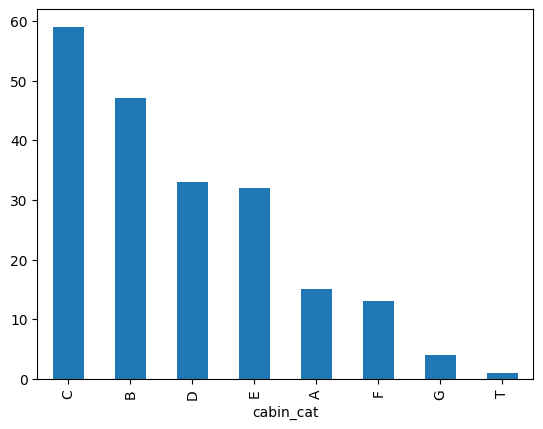

In [19]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [23]:
# Extract the last part of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors='coerce', downcast='integer')

# Extract the first part of ticket as categorical
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan, df['ticket_cat'])

In [29]:
df.sample(5+3)

,Survived,Ticket,Cabin,family,family_numerical,family_categorical,cabin_cat,cabin_num,ticket_num,ticket_cat
214,0,367229,NaN,1,1.0,NaN,NaN,NaN,367229.0,NaN
664,1,STON/O 2. 3101285,NaN,1,1.0,NaN,NaN,NaN,3101285.0,STON/O
114,0,2627,NaN,A,NaN,A,NaN,NaN,2627.0,NaN
89,0,343275,NaN,A,NaN,A,NaN,NaN,343275.0,NaN
526,1,W./C. 14258,NaN,A,NaN,A,NaN,NaN,14258.0,W./C.
36,1,2677,NaN,A,NaN,A,NaN,NaN,2677.0,NaN
29,0,349216,NaN,A,NaN,A,NaN,NaN,349216.0,NaN
858,1,2666,NaN,3,3.0,NaN,NaN,NaN,2666.0,NaN
